In [7]:
import pandas as pd

Purpose

Test if models trained on real bulk are good at learning the simulated brain enriched functions

In [8]:
df = pd.read_csv("/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/bulkEGADPipeline/results/realbulk_simbrainlabels/EGAD/melted_dfs/Brain_split.csv_melted_EGADs.csv.gz").reset_index()
df['group'] = df.loc[:,'index'].str.split("_").str[2]
df = df.query("group!='Q1'")
df

,level_0,Unnamed: 0,index,bootstrap,auc,group
999,999,999,SIMGO_1_Q2,5,0.400813,Q2
1000,1000,1000,SIMGO_2_Q2,5,0.479375,Q2
1001,1001,1001,SIMGO_3_Q2,5,0.576115,Q2
1002,1002,1002,SIMGO_4_Q2,5,0.355191,Q2
1003,1003,1003,SIMGO_5_Q2,5,0.504863,Q2
...,...,...,...,...,...,...
149845,149845,2992,SIMGO_995_Q3,34,0.798703,Q3
149846,149846,2993,SIMGO_996_Q3,34,0.735096,Q3
149847,149847,2994,SIMGO_997_Q3,34,0.695414,Q3
149848,149848,2995,SIMGO_998_Q3,34,0.636549,Q3


In [9]:
import statsmodels.formula.api as smf
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

df['go_num'] = df['index'].str.split('_').str[1]
df_agg = df.groupby(['go_num', 'group'])['auc'].mean().reset_index()

try:
    with warnings.catch_warnings():
        warnings.filterwarnings("error", category=ConvergenceWarning)
        warnings.filterwarnings("error", category=UserWarning)
        lme_model = smf.mixedlm('auc ~ C(group)', df_agg, groups=df_agg['go_num'])
        result = lme_model.fit(method='lbfgs')
    print(result.summary())
except (ConvergenceWarning, UserWarning) as e:
    print(f"NOTE: Mixed effects model failed to converge ({e}). Falling back to t-test.")
    result = None

NOTE: Mixed effects model failed to converge (Random effects covariance is singular). Falling back to t-test.


In [11]:
if result is not None:
    coef_df = pd.DataFrame({
        'coef': result.fe_params,
        'std_err': result.bse_fe,
        'z': result.tvalues,
        'p_value': result.pvalues
    }).dropna()
    coef_df.to_csv("results/learnability_mixedlm_coefficients.csv")
    display(coef_df)
else:
    print("Skipping: mixed model did not converge.")

Skipping: mixed model did not converge.


/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/learnability_boxplot.png
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 1.5 x 1 in image.
/home/aadrian/miniforge3/envs/main_env/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: results/learnability_boxplot.pdf


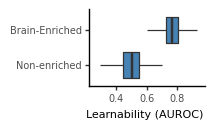

<ggplot: (8781502898195)>

In [24]:
from plotnine import *

p = (
    ggplot(
        df,
        aes(x='group', y='auc')
    )
    + geom_boxplot(outlier_alpha=0, fill='steelblue')
    + scale_x_discrete(labels=['Non-enriched', 'Brain-Enriched'])
    + labs(
        x='',
        y='Learnability (AUROC)'
    )
    + theme_classic()
    + theme(
        figure_size=(1.5, 1),
        axis_text_x=element_text(rotation=0, size=7),
        axis_text_y=element_text(rotation=0,size=7),
        axis_title_y=element_text(size=8),
        axis_title_x=element_text(size=8),
        legend_position='none'
    )
    + scale_color_brewer(type='qual', palette='Dark2')
    +coord_flip()
) 

p.save("results/learnability_boxplot.png", dpi=300)
p.save("results/learnability_boxplot.pdf")

p

In [13]:
if result is not None:
    intercept = result.fe_params['Intercept']
    slopes_df = pd.DataFrame({
        'group': ['Q2', 'Q3'],
        'predicted_mean_auc': [
            intercept,
            intercept + result.fe_params['C(group)[T.Q3]'],
        ]
    })
    slopes_df.to_csv("results/slopes.csv", index=False)
    display(slopes_df)
else:
    print("Skipping: mixed model did not converge.")

Skipping: mixed model did not converge.


In [14]:
from scipy import stats

q2 = df_agg[df_agg['group'] == 'Q2']['auc']
q3 = df_agg[df_agg['group'] == 'Q3']['auc']

t_stat, p_val = stats.ttest_ind(q2, q3)

ttest_df = pd.DataFrame({
    'comparison': ['Q2 vs Q3'],
    'mean_Q2': [q2.mean()],
    'mean_Q3': [q3.mean()],
    't_stat': [t_stat],
    'p_value': [p_val]
})

ttest_df.to_csv("results/ttest_results.csv", index=False)
ttest_df

,comparison,mean_Q2,mean_Q3,t_stat,p_value
0,Q2 vs Q3,0.500027,0.761941,-136.971126,0.0
